In [2]:
import os
import pickle
import warnings
warnings.filterwarnings('ignore')
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from Utils.download import download_signal_EEG, data_time_to_load
from Utils.LSTM_net import CNN_LSTM_Model
from Utils.train import evaluar_modelo_clasificador, data_train, train


import mne
from scipy.io import loadmat


from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV, cross_val_score, train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score, roc_auc_score, roc_curve, precision_score, auc 
from sklearn.preprocessing import StandardScaler



import torch
import torch.nn as nn
import torch.optim as optim
from transformers import get_linear_schedule_with_warmup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
np.random.seed(0)

In [3]:
df_times=pd.read_csv("d/data_features.csv",sep=";")
# patients=pd.Series([(pat, num, hour) for (pat, num, hour) in zip(df_times["patient"],df_times["number_file"],
#                                                                  df_times["hour_file"])]).unique().tolist()
df_times["file"]=df_times["file"].apply(lambda x: x.split(".")[0])
df_times["path"]=df_times["path"].apply(lambda x: x.split(".")[0])
df_times.drop(columns=["file_extension","meas_date"], inplace=True)
df_times.drop_duplicates(subset=["file"],inplace=True)
df_times.sort_values(by=["patient", "hour_file", "number_file", "format_data"], inplace=True)
df_times.head()

,id_path,path,data_partition,patient,file,number_file,hour_file,format_data,minutes,#_channels,channels,fs,time_points
0,533daaa14eb9f3df83a6d8da27674eef8c8cb461617fdb...,training/0284/0284_001_004_ECG,training,284,0284_001_004_ECG,1,4,ECG,52.62,1.0,ECG,500.0,1578500.0
229,b60649491c45d43cf5e55a4e84f17286fa2498fe6d4f60...,training/0284/0284_001_004_EEG,training,284,0284_001_004_EEG,1,4,EEG,52.62,19.0,"Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T3,T4,T5...",500.0,1578500.0
227,29a8271fe7391ce372b58725a117a9ac63bdd8953ad617...,training/0284/0284_002_005_ECG,training,284,0284_002_005_ECG,2,5,ECG,60.00,1.0,ECG,500.0,1800000.0
225,3f43c187a0c01e5ba963da202174c999840d8595fb6455...,training/0284/0284_002_005_EEG,training,284,0284_002_005_EEG,2,5,EEG,60.00,19.0,"Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T3,T4,T5...",500.0,1800000.0
223,e9a9212c929a90bf0f37196caa42380cd433d35fff0aab...,training/0284/0284_003_006_ECG,training,284,0284_003_006_ECG,3,6,ECG,60.00,1.0,ECG,500.0,1800000.0


Tomar 1-5 minutos en las horas 12, 24, 36 ,48, 60 y 72, si no hay ese rango horario, tomar las 2 horas últimas que se encuentren sin artefactos en reverso de 5 minutos

Sacar subintervalos sobre todas la horas para caracterizar el tiempo completo
Tener en cuenta el historial en las predicciones. 
Influencia del sedante sobre el paciente antes y después de las 48 horas según regla estándar
Tener en cuenta ROSC y no tenerlo en cuenta


Señales biológicas EEG, dejar opcional remoción de artefactos ICA e (importante: interpolación de canales criterio entre canales sin eliminar señales planas)


In [4]:
# df_prove=df_times[(df_times["patient"].between(991,994)) & (df_times["hour_file"]==48)]
# save_data="C:/Users/THIN/OneDrive - Escuela Tecnologica Instituto Tecnico Central/Proyecto_cerebro/Code/prove/"
# raw_list, ref_data, errors_interpolate, rejected= download_signal_EEG(data_patients=df_prove,
#                                             hour_list=[48],
#                                             download_paht=save_data, 
#                                             k_proving=None, 
#                                             remove_data=True,
#                                             interval_times=[(0,300)],
#                                             fs_resampled=128, 
#                                             get_errors=True)

In [ ]:
save_data="C:/Users/THIN/OneDrive - Escuela Tecnologica Instituto Tecnico Central/Proyecto_cerebro/Code/prove/"
raw_list, ref_data, errors_interpolate, rejected = download_signal_EEG(data_patients=df_times,
                                            hour_list=[36],
                                            download_paht=save_data, 
                                            k_proving=None, 
                                            remove_data=True,
                                            interval_times=[(0,300)],
                                            fs_resampled=128, 
                                            get_errors=True)
patients=[i[:4] for i in errors_interpolate.keys()]


________________________________________
downloading from path: training/0284/0284_037_036_EEG.mat part 1...
downloading from path: training/0284/0284_037_036_EEG.hea part 1...
0284
________________________________________
downloading from path: training/0284/0284_038_036_EEG.mat part 2...
downloading from path: training/0284/0284_038_036_EEG.hea part 2...
0284
Filtering raw data in 2 contiguous segments
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 3301 samples (6.602 s)

NOTE: pick_types() is a legacy function. New code should use inst.pick(

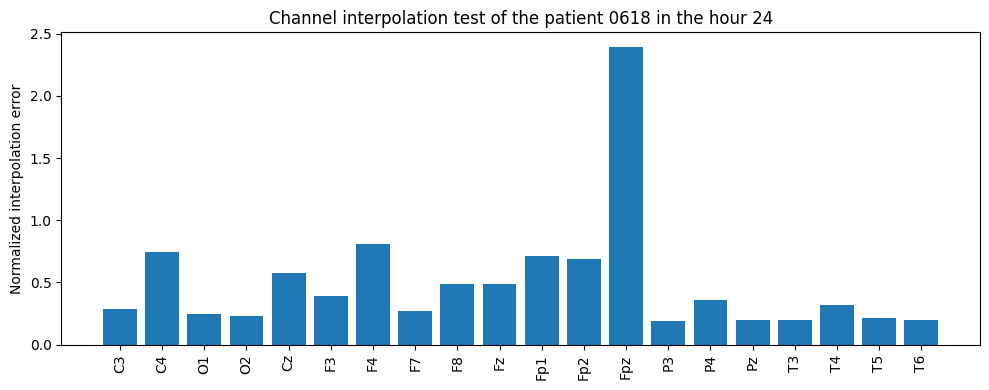

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


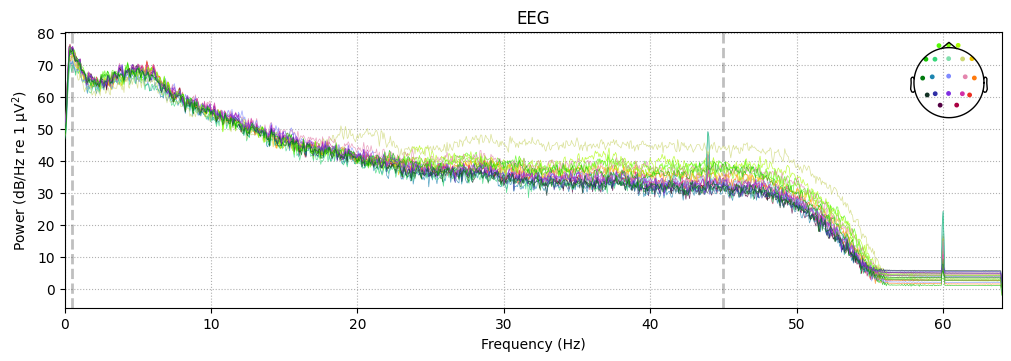

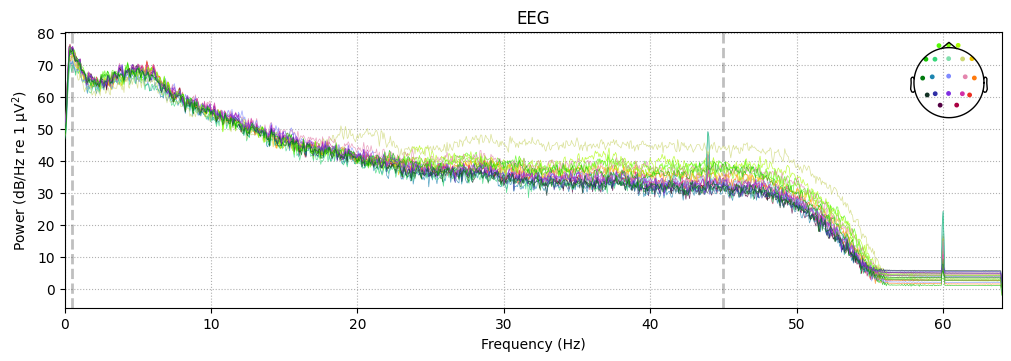

In [5]:
pat_num=200
patients_hours=[i for i in errors_interpolate.keys()]
errors=errors_interpolate[patients_hours[pat_num]]

plt.figure(figsize=(10, 4))
plt.bar(errors.keys(), errors.values())
plt.xticks(rotation=90)
plt.ylabel(f"Normalized interpolation error")
plt.title(f"Channel interpolation test of the patient {patients_hours[pat_num][:4]} in the hour {patients_hours[pat_num][4:]}")
plt.tight_layout()
plt.show()

raw_list[pat_num].set_montage("standard_1020")
raw_list[pat_num].pick_types(eeg=True)
raw_list[pat_num].plot_psd()

In [7]:
channels=['Fp1', 'Fp2','F3','F4','C3','C4','P3','P4','O1','O2','F7','F8','T3','T4','T5','T6','Fz','Cz','Pz']

path_demographic="d/data_patients.csv"

### Data base demographic
df_demog=pd.read_csv(path_demographic, sep=";" )
df_demog["numeric_outcome"]=df_demog["Outcome"].map({"Good": 1, "Poor": 0})
df_demog.reset_index(drop=True, inplace=True)
df_demog.isnull().sum()

Id_Patient            0
Hospital              0
Age                   1
Sex                   3
ROSC                304
OHCA                 41
Shockable Rhythm     32
TTM                  98
Outcome               0
CPC                   0
numeric_outcome       0
dtype: int64

In [8]:
wind_size=256
data, demograp_data = data_train(raw_list=raw_list, df_demog=df_demog, wind_size=wind_size, over_lap=64, patients=patients, channels=channels)
# X_eeg= torch.stack(data, dim=0)
X_eeg=torch.cat(data,dim=0)
del data
X_eeg=X_eeg.reshape(len(demograp_data),X_eeg.shape[0]//len(demograp_data),19, wind_size)
Y_eeg= torch.tensor(np.array(demograp_data["numeric_outcome"],dtype=float)).long()
# Y_eeg= torch.tensor(np.array(demograp_data["CPC"],dtype=float)).long()

X_train, X_test, y_train, y_test= train_test_split(X_eeg, Y_eeg, test_size=0.25, random_state=0, stratify=Y_eeg)
num_classes=len(Y_eeg.unique())

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model_LSTM=CNN_LSTM_Model(num_classes=num_classes, cnn_out=32, lstm_hidden=32, lstm_layers=2).to(device)
X_eeg.shape


torch.Size([476, 200, 19, 256])

In [ ]:
def eval(model, X_test, y_test, model_name:str, Acc_scores:list, Loss_scores:list,
         S_labels:[str]):
    model.eval()
    with torch.no_grad():
        logits = model(X_test.float().to(device))
        y_pred = torch.argmax(torch.softmax(logits, dim=1), dim=1)
        y_score=torch.softmax(logits, dim=1).cpu()
        # acc = (y_pred == y_test.to(device)).float().mean().item()
        y_pred=y_pred.cpu()

        plt.plot(sorted(Acc_scores))
        plt.title("Accuraccy performance")
        plt.xlabel("epochs")
        plt.ylabel("Accuracy")
        plt.show()
        plt.plot(sorted(Loss_scores, reverse=True))
        plt.title("Loss performance")
        plt.xlabel("epochs")
        plt.ylabel("Loss")
        plt.show()
    m_conf=confusion_matrix(y_test, y_pred)
    # S_labels=["Poor", "Good"]
    accuracy_test=accuracy_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred,average="weighted")
    precision=precision_score(y_test,y_pred,average="weighted")
    f1=f1_score(y_test,y_pred,average="weighted")
    sns.heatmap(m_conf, annot=True, fmt="d", xticklabels=S_labels, yticklabels=S_labels)
    plt.title(f"{model_name}, accuracy_test= {round((accuracy_test),2)}")

    print("Exactitud: ",accuracy_test)
    print("Exhaustividad: ", recall)
    print("Precisión", precision)
    print("f1_score", f1)

    # Si el modelo es de dos clases
    if len(torch.unique(y_test))==2:
        fpr, tpr, thresholds = roc_curve(y_test, y_score=y_score[:,1])
        roc_auc = auc(fpr, tpr)

        # 6. Graficar la curva ROC
        plt.figure(figsize=(7,5))
        plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatorio')
        plt.xlabel('Tasa de falsos positivos (FPR)')
        plt.ylabel('Tasa de verdaderos positivos (TPR)')
        plt.title('Curva ROC - Clasificación binaria')
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.show()

In [11]:
demograp_data.to_csv("C:/Users/THIN/OneDrive - Escuela Tecnologica Instituto Tecnico Central/Proyecto_cerebro/Code/date_send/demographic_24_w256_ov64.csv", index=False)
torch.save(X_eeg, "C:/Users/THIN/OneDrive - Escuela Tecnologica Instituto Tecnico Central/Proyecto_cerebro/Code/date_send/X_features_24_w256_ov64.pt")

In [ ]:
model_LSTM, Loss_scores, Acc_scores = train(model=model_LSTM, X_train=X_train, y_train=y_train, cv=cv, batch_size=16, epochs=100, device=device)

KeyboardInterrupt: 

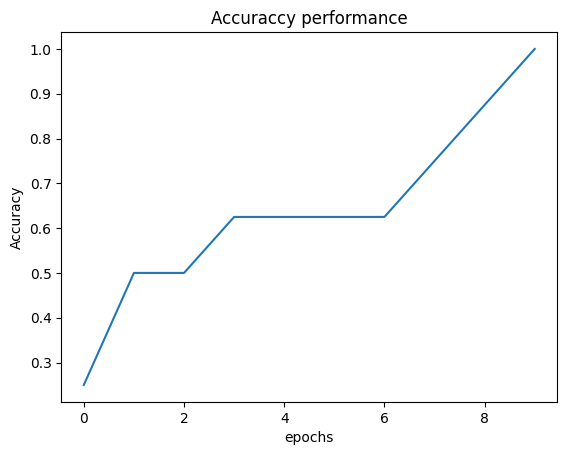

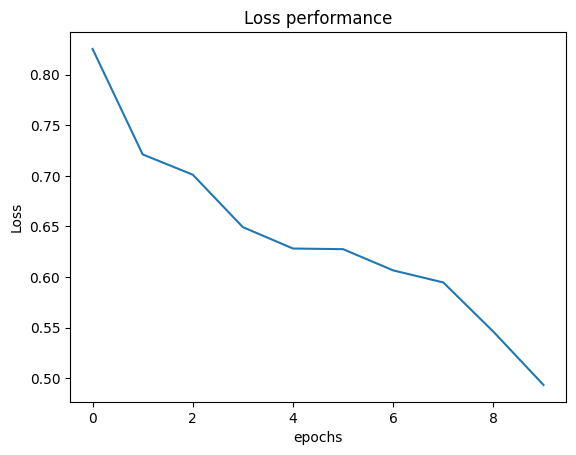

Exactitud:  0.6
Exhaustividad:  0.6
Precisión 0.36
f1_score 0.45


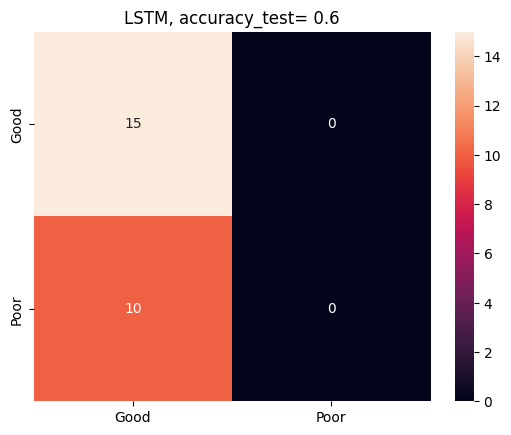

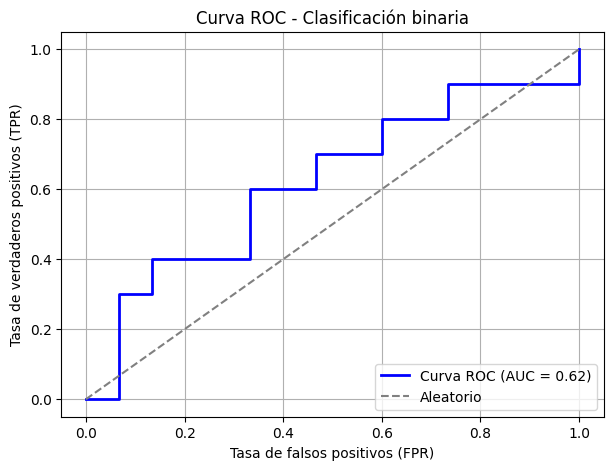

In [ ]:
eval(model=model_LSTM, X_test=X_test, y_test=y_test, model_name="LSTM", Acc_scores=Acc_scores, Loss_scores=Loss_scores,S_labels=["Good", "Poor"])